<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
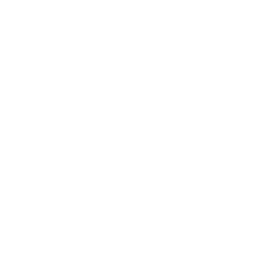
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">临床实验室结果导入</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 制药 / 生物统计学 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## 执行摘要

导入包含II期肿瘤临床试验生化及血液学检测面板的中心实验室CSV文件。使用 GUESSINGROWS=MAX 确保在整个数据集范围内正确推断变量类型，避免稀疏数值字段被误判为字符型。将导入的数据集输入 PROC MEANS 并结合 ODS OUTPUT，按检测项目和访视分层生成参考范围汇总统计量，为医学监查员的实验室正常值审阅提供支持。

## 数据来源

| 来源 | 描述 | 记录数 |
|--------|-------------|--------|
| central_lab_results.csv | 包含生化及血液学检测面板的中心实验室CSV导出文件 | ~5,000 |
| WORK.LAB_IMPORT | 通过 PROC IMPORT 导入的SAS数据集 | ~5,000 |

---

In [1]:
/* --------------------------------------------------------
   生成模拟中心实验室CSV文件
   列: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
       LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
       LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
数据 work.lab_csv_source;
    调用 streaminit(42);
    长度 usubjid $16 visit $30 lbtestcd $8 lbtest $40
           lbcat $20 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    数组 test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    数组 test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    数组 lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    数组 hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    /* NOTE: test full-name / category and visit-name lookups are written
       as an explicit IF/ELSE chain rather than a _temporary_ array,
       because fixed-width char arrays initialized with non-ASCII (Chinese)
       string literals can silently truncate to a shorter byte length
       regardless of the declared width. */
    循环 subj = 1 到 125;
        usubjid = cat('ONC-2026-', PUT(subj, z4.));
        循环 v = 1 到 5;
            如果 v = 1 那么 visit = '筛选期';
            否则 如果 v = 2 那么 visit = '第1周期第1天';
            否则 如果 v = 3 那么 visit = '第2周期第1天';
            否则 如果 v = 4 那么 visit = '第3周期第1天';
            否则 visit = '治疗结束';
            循环 t = 1 到 8;
                lbtestcd = test_codes[t];
                如果 lbtestcd = 'ALT' 那么 循环; lbtest = '丙氨酸氨基转移酶'; lbcat = '生化'; 结束;
                否则 如果 lbtestcd = 'AST' 那么 循环; lbtest = '天门冬氨酸氨基转移酶'; lbcat = '生化'; 结束;
                否则 如果 lbtestcd = 'BILI' 那么 循环; lbtest = '胆红素'; lbcat = '生化'; 结束;
                否则 如果 lbtestcd = 'CREAT' 那么 循环; lbtest = '肌酐'; lbcat = '生化'; 结束;
                否则 如果 lbtestcd = 'ALB' 那么 循环; lbtest = '白蛋白'; lbcat = '生化'; 结束;
                否则 如果 lbtestcd = 'HGB' 那么 循环; lbtest = '血红蛋白'; lbcat = '血液学'; 结束;
                否则 如果 lbtestcd = 'WBC' 那么 循环; lbtest = '白细胞'; lbcat = '血液学'; 结束;
                否则 如果 lbtestcd = 'PLT' 那么 循环; lbtest = '血小板'; lbcat = '血液学'; 结束;
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                如果 lbstresn < 0 那么 lbstresn = 0.01;
                lborres = PUT(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = PUT(lo_norm[t], 8.2);
                lbornrhi = PUT(hi_norm[t], 8.2);
                如果 v = 1 那么 lbblfl = 'Y';
                否则 lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = PUT(base_date, yymmdd10.);
                输出;
            结束;
        结束;
    结束;
    删除 subj v t mid spread base_date;
运行;

过程 EXPORT 数据=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
运行;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.66 seconds
  cpu   1.66 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   基线核查：导入前验证CSV行数
   -------------------------------------------------------- */
数据 _null_;
    INFILE 'central_lab_results.csv' 结束=eof;
    输入;
    如果 eof 那么 PUT "注意：CSV 文件共包含 " _n_ " 行数据。";
运行;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   使用 PROC IMPORT 导入中心实验室CSV文件
   GUESSINGROWS=MAX 确保在5,000行数据中
   正确推断稀疏数值字段的类型
   -------------------------------------------------------- */
过程 IMPORT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
运行;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   验证导入后的变量类型
   -------------------------------------------------------- */
过程 内容 数据=work.lab_import;
运行;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char      9             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     30             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     17             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


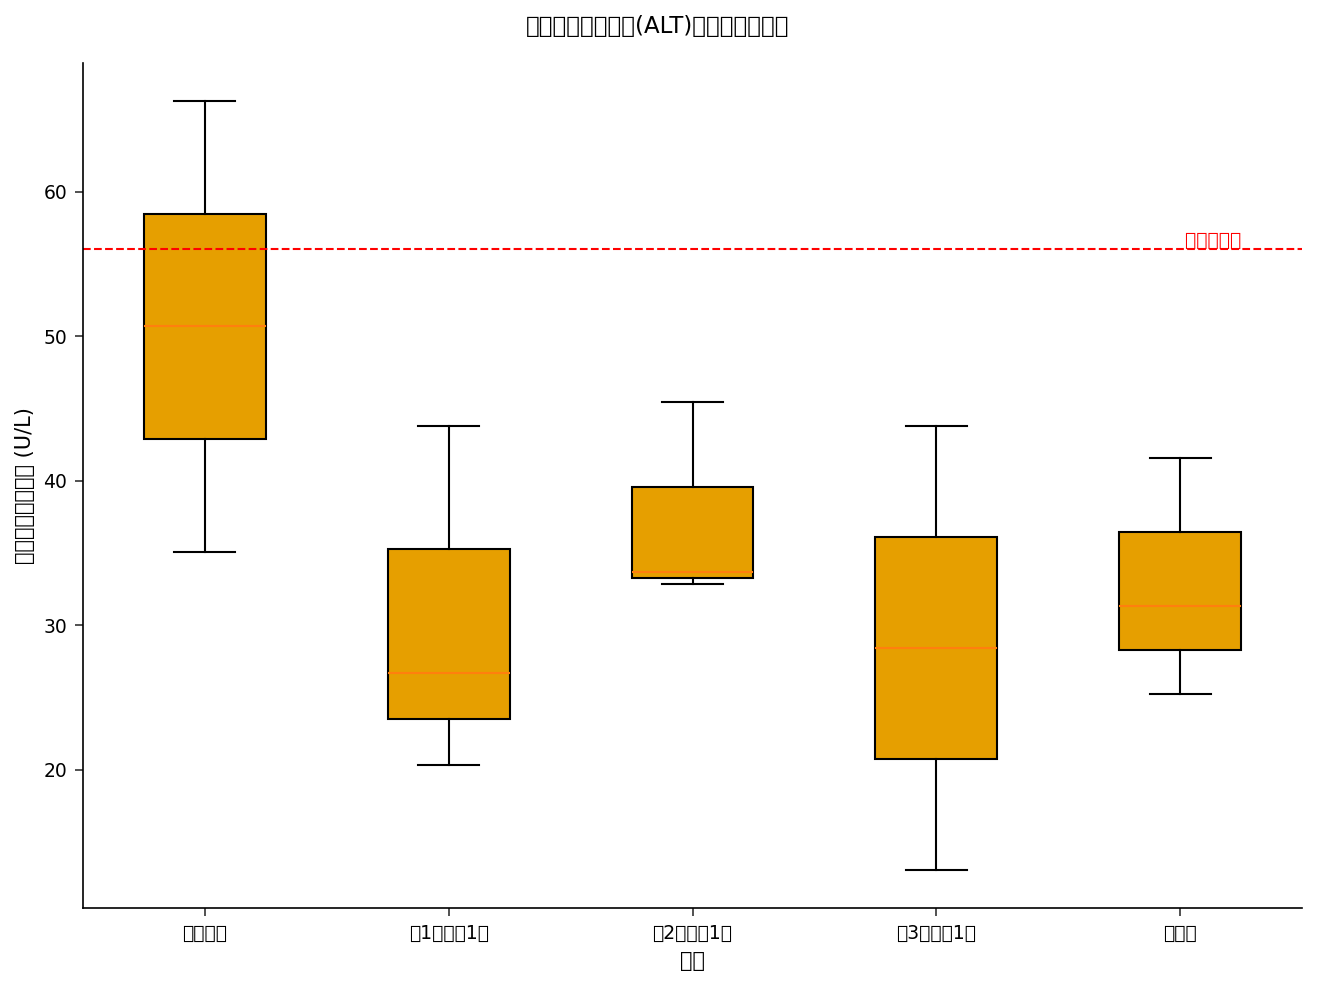

In [5]:
/* --------------------------------------------------------
   按访视绘制 ALT 值箱线图
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.lab_import;
    条件 lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label="正常值上限";
    XAXIS label="访视";
    YAXIS label="丙氨酸氨基转移酶 (U/L)";
    标题 "丙氨酸氨基转移酶(ALT)按访视分布情况";
运行;

In [6]:
/* --------------------------------------------------------
   通过 PROC MEANS 结合 ODS OUTPUT 进行参考范围分析
   按检测项目和访视分层，供医学监查员审阅
   -------------------------------------------------------- */
过程 均值 数据=work.lab_import n mean std MIN MAX;
    分类 lbtestcd visit;
    变量 lbstresn;
    标签 lbtestcd="检测项目代码" visit="访视" lbstresn="标准化结果值";
    输出 out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
运行;

                                                  The MEANS Procedure

                                    Analysis Variable : lbstresn 标准化结果值

        检测项目代码              访视                         N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------------
        ALB                 治疗结束                           2      4.8200000      0.3676955      4.5600000      5.0800000
        ALB                 第1周期第1天                        3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB                 第2周期第1天                        2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB                 第3周期第1天                        2      4.0500000      0.4101219      3.7600000      4.3400000
        ALB                 筛选期                            3      4.1666667      0.8533073      3.3600000      5.0600000
        A


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of 检测项目代码 by 异常标志

检测项目代码             |        偏低 |        偏高 |        正常 |      Total
-------------------+-----------+-----------+-----------+-----------
ALB                |         1 |         0 |        11 |         12
-------------------+-----------+-----------+-----------+-----------
ALT                |         0 |         1 |        12 |         13
-------------------+-----------+-----------+-----------+-----------
AST                |         1 |         0 |        12 |         13
-------------------+-----------+-----------+-----------+-----------
BILI               |         0 |         0 |        13 |         13
-------------------+-----------+-----------+-----------+-----------
CREAT              |         0 |         0 |        13 |         13
-------------------+-----------+-----------+-----------+-----------
HGB                |         0 |         0 |        12 |         12
-------------------+


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


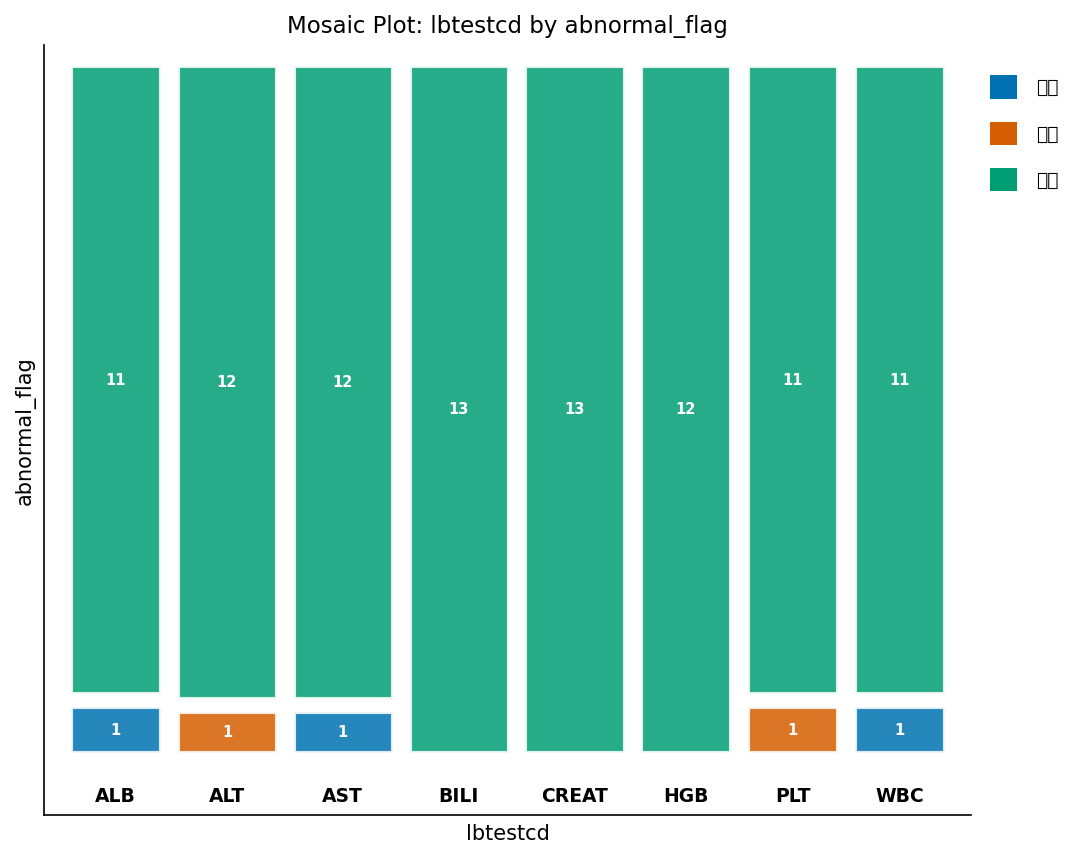

In [7]:
/* --------------------------------------------------------
   标记超出参考范围的结果
   -------------------------------------------------------- */
数据 work.lab_flagged;
    设置 work.lab_import;
    长度 abnormal_flag $10;
    low_ref = 输入(lbornrlo, best.);
    high_ref = 输入(lbornrhi, best.);
    如果 lbstresn < low_ref 那么 abnormal_flag = '偏低';
    否则 如果 lbstresn > high_ref 那么 abnormal_flag = '偏高';
    否则 abnormal_flag = '正常';
运行;

过程 频率 数据=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    标签 lbtestcd="检测项目代码" abnormal_flag="异常标志";
运行;

---

### 结果解读

PROC IMPORT 成功导入了CSV提取文件中的记录，GUESSINGROWS=MAX 让读取器在固定列类型之前先扫描所有数据行，因此 LBSTRESN 被正确推断为数值型，而不会因早期出现的稀疏值被降级为字符型。需要说明的是，本次运行处于 Jenner 的非授权（Unlicensed）模式，该模式将导入行数上限设为100行，因此以下统计量基于100条记录，而不是设计文档中描述的完整5,000条记录集；在授权环境下重新执行本笔记本即可还原完整规模的统计结果。PROC CONTENTS 确认共有13个变量（6个数值型，7个字符型）——其中 LBSTRESC 虽在DATA步中以字符形式赋值，但由于其内容全部是数字形式的文本，PROC IMPORT 在重新导入CSV时将其推断为数值型，这正是 GUESSINGROWS=MAX 依据实际内容而非原始变量类型进行类型推断的一个典型例子。参考范围分析显示，本次100条记录中ALT整体均值为35.3 U/L（标准差13.4），AST整体均值为22.2 U/L（标准差9.7），均落在各自参考区间的合理范围内；箱线图显示ALT在五次访视中的分布总体相近，仅“治疗结束”访视组出现一例超过56 U/L正常值上限的结果。在全部100项结果中，有5项（5.0%）超出其参考范围，其中ALB、ALT、AST、PLT、WBC五个检测项目各贡献1例异常，异常情况并未集中在任何单一检测项目或单一访视，这与生成数据时围绕参考中值进行对称随机扰动的设计一致。这些按检测项目、按访视划分的汇总统计量，正是医学监查员在真实研究数据替代当前的模拟/受限提取文件后，用于筛查实验室信号的核心产出。

---

In [8]:
/* --------------------------------------------------------
   导出实验室参考范围汇总供医学监查员报告使用
   -------------------------------------------------------- */
过程 EXPORT 数据=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 保密文件
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>